# Guaranteed Hedge -- Optimization Formulation (No Fitted Parameters)

Replaces the coverage/moneyness/DTE sweep entirely. No train/test split, because nothing
here is estimated from history -- every decision below is a small constrained optimization
solved using only the option chain observable *on that day*.

**Tier 1 (mathematically guaranteed):** short $n$ shares of TSLL + long $n/100$ TSLL calls,
share-matched (not delta-matched). For strike $K$, premium $C$: worst-case loss from here
forward, for ANY future price, is exactly $K - S_0 + C$ (derived via payoff algebra + the
no-arbitrage floor "option price >= intrinsic value" -- true at every point in time, not
just at expiry). This requires the option to be on TSLL itself; it does NOT depend on the
option "tracking" the stock, only on that one no-arbitrage inequality.

**The optimization, solved fresh at every re-hedge event:**

$$\min_{(K,T) \in \mathcal{C}_t} C(K,T) \quad \text{s.t.} \quad K - S_0 + C(K,T) \le L \cdot S_0$$

where $\mathcal{C}_t$ = TSLL calls actually listed and liquid today, $L$ = PM's loss
tolerance (10%). Cheapest contract that keeps the guarantee inside budget wins.

**Re-hedge events (never a calendar):**
1. Forced: held contract is within `MIN_DTE_BUFFER` days of expiry (mechanical necessity,
   not a tuned threshold -- just enough runway to execute the exit).
2. Restoration: currently on Tier 2 (fallback) and a Tier-1-feasible contract exists today.

**Tier 2 (fallback, NOT guaranteed):** used only when no TSLL call satisfies the Tier-1
constraint at any strike -- this is "the math doesn't suit" from the chat. Falls back to
the existing BS-delta/coverage-ratio sizing on TSLA calls (more liquid, cheaper, but its
protection depends on TSLL actually tracking ~2x TSLA, a model assumption, not a contract).

The guarantee is **rolling**: renewed relative to TSLL's spot at the moment of each
re-hedge, not the strategy's original inception price -- "you will not lose more than 10%
from here forward, until the next event" rather than a single lifetime bound.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls, load_tsll_calls
from options_selection import select_contract, bs_delta
from metrics import summarize
from cba_backtest import R_RF, TSLL_LEVER

%matplotlib inline

VOL_WINDOW = 21
LOSS_TOLERANCE = 0.10       # PM's mandate: never lose more than 10%, inclusive of hedge cost
MIN_DTE_BUFFER = 5          # mechanical -- just enough runway to exit, not a tuned parameter
MAX_DTE_SEARCH = 400        # search window for available TSLL contracts, not a fitted target
MIN_DTE_SEARCH = 60         # floor on tenor -- without this the cheapest-premium objective
                            # keeps picking near-dated contracts, forcing near-constant
                            # turnover; this is a sanity floor, not a fitted target
COVERAGE_BAND = (0.5, 2.0)  # Tier-2 monitoring band, same one already validated in
                            # cba_ensemble_sandbox.ipynb -- Tier 2 has no algebraic
                            # guarantee, so this is the best-effort proxy for "is the
                            # modeled protection still adequate"
NOTIONAL_GRID = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]  # fractions of the
                            # ORIGINAL $1 notional, fixed -- not relative to whatever
                            # size is currently held. Searched fresh (largest first) at
                            # every re-hedge event, so the same search both deleverages
                            # when conditions worsen and re-levers when they improve,
                            # with no path-dependent compounding.
TSLA_COST_PCT = 0.01        # transaction-cost assumption, matches grid_search.py's "base" scenario


In [2]:
tsll = load_tsll()
tsll_spot_full = tsll.set_index("Date")["Close"]

tsla_spot_full = load_tsla_underlying().set_index("Date")["Close"].reindex(tsll_spot_full.index).ffill()
tsla_sigma_full = (tsla_spot_full.pct_change().rolling(VOL_WINDOW).std() * (252 ** 0.5)).ffill().bfill()
tsll_sigma_full = (tsll_spot_full.pct_change().rolling(VOL_WINDOW).std() * (252 ** 0.5)).ffill().bfill()

tsll_calls = load_tsll_calls()
tsla_calls = load_tsla_calls()
tsla_lookup = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
tsla_vol_lookup = tsla_calls.set_index(["raw_id", "date"])["px_volume"].to_dict()
tsll_lookup = tsll_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
tsll_vol_lookup = tsll_calls.set_index(["raw_id", "date"])["px_volume"].to_dict()

dates = tsll_spot_full.index
print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")
print(f"TSLL calls: {len(tsll_calls):,} rows, TSLA calls: {len(tsla_calls):,} rows")


963 trading days, 2022-08-09 -> 2026-06-10
TSLL calls: 46,867 rows, TSLA calls: 532,258 rows


## Tier 1 optimizer: cheapest TSLL call that keeps drawdown-from-peak inside budget

Constraint is now anchored to the running high-water mark, not the strategy's original
capital or a per-cycle reset: the position must never let equity fall more than
`loss_tolerance` below the **peak equity ever reached**. "OK to give back profits, never
breach the limit" -- profits raise the bar (a new peak requires re-checking whether the
held/candidate position still protects against a deeper floor), losses that stay above the
last peak's floor require no action at all.

For a candidate contract $(K, C)$: worst-case future equity (if price keeps rising past
$K$, forever) is $V_t + n_{shares}\cdot(S_t - K - C)$. Feasible iff that floor is still
$\ge (1-L)\cdot P_t$, where $P_t$ is the peak-to-date and $V_t$ is today's mark.

In [3]:
def find_cheapest_guaranteed_call(calls_df, spot_val, date, loss_tolerance,
                                  n_shares, peak_equity, current_equity,
                                  max_dte=MAX_DTE_SEARCH, min_dte=MIN_DTE_SEARCH):
    day = calls_df[calls_df["date"] == date]
    if day.empty:
        return None
    dte = (day["expiry"] - date).dt.days
    mask = (
        (dte >= min_dte) & (dte <= max_dte)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    candidates = day[mask].copy()
    if candidates.empty:
        return None
    candidates["worst_case_equity"] = (
        current_equity + n_shares * (spot_val - candidates["strike"] - candidates["px_last"])
    )
    floor = (1 - loss_tolerance) * peak_equity
    feasible = candidates[candidates["worst_case_equity"] >= floor]
    if feasible.empty:
        return None
    return feasible.loc[feasible["px_last"].idxmin()]


def held_tier1_still_sufficient(position, spot_val, n_shares, loss_tolerance, peak_equity, current_equity):
    """Check an ALREADY-HELD Tier-1 contract against a (possibly just-updated) peak --
    no new premium to pay, so the floor uses the strike alone, not strike+premium."""
    worst_case_equity = current_equity + n_shares * (spot_val - position["strike"])
    return worst_case_equity >= (1 - loss_tolerance) * peak_equity


## Tier 2 fallback: cheapest-strike search, not a fixed moneyness

Previously defaulted to ATM, which turned out to be a real bug, not a stylistic choice:
delta-based sizing already hits the same target dollar-delta coverage at ANY moneyness (n
scales inversely with delta to compensate), so the strike choice doesn't change protection
quality at the moment of purchase -- it only changes total premium cost, which varies by
where the vol surface happens to be cheap that day. Defaulting to ATM meant repeatedly
rebuying the *most* expensive moneyness every time the coverage-drift monitor fired during
a crash (confirmed: -1.66 in option P&L from 9 ATM rebuys during the 2022 crash alone).

Also switching OTM by default was considered and rejected: OTM calls are cheaper per
purchase, but their delta collapses faster as spot moves away from the strike (the same
mechanism that made the original 20% OTM bucket the worst performer in the very first
report), so a fixed cheaper moneyness could mean *faster*-degrading coverage, not better
protection. Searching every available strike for whichever is cheapest that specific day
avoids betting on either fixed convention.

If even the cheapest available contract would cost enough to itself breach the
peak-relative floor, that's not "too expensive, skip it" -- it's "this notional isn't
affordably protectable right now," and the same `NOTIONAL_SHRINK_GRID` used for Tier 1
applies here too, tried in `establish_new_position` below.

In [4]:
MONEYNESS_LO, MONEYNESS_HI = 0.80, 1.30  # bounds the strike search -- without this, minimizing
                                          # raw premium for a fixed dollar-delta target systematically
                                          # picks deep-OTM, near-zero-priced, high-gamma "lottery ticket"
                                          # options (confirmed: a 69%-OTM $350 strike got picked while
                                          # spot was ~$207-274, producing a 22x price swing on a routine
                                          # TSLA rally). Bounding to the same rough range this project's
                                          # ATM/10%/20% OTM buckets already span keeps the cost search
                                          # honest instead of convexity-seeking.

def find_cheapest_tier2_call(spot_val, sigma_val, notional, date, max_dte=MAX_DTE_SEARCH, min_dte=MIN_DTE_SEARCH):
    """Search available TSLA calls within a sane moneyness band (not unbounded, not one
    fixed bucket), size each to hit the same target dollar-delta coverage, and return
    whichever is cheapest in total premium. Returns a dict with a `premium_cost` key (total
    $ to establish), or None if no contract clears the liquidity bar that day."""
    day = tsla_calls[tsla_calls["date"] == date]
    if day.empty:
        return None
    dte = (day["expiry"] - date).dt.days
    moneyness = day["strike"] / spot_val
    mask = (
        (dte >= min_dte) & (dte <= max_dte)
        & (moneyness >= MONEYNESS_LO) & (moneyness <= MONEYNESS_HI)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    candidates = day[mask].copy()
    if candidates.empty:
        return None

    T_years = ((candidates["expiry"] - date).dt.days / 365.25).clip(lower=1 / 365)
    deltas = [bs_delta(spot_val, k, t, R_RF, sigma_val) for k, t in zip(candidates["strike"], T_years)]
    deltas = np.clip(deltas, 0.01, 1.0)
    n = TSLL_LEVER * notional / (deltas * 100 * spot_val)
    total_cost = n * 100 * candidates["px_last"].to_numpy()

    idx_pos = int(np.argmin(total_cost))
    best = candidates.iloc[idx_pos]
    return {
        "tier": 2, "raw_id": best["raw_id"], "strike": float(best["strike"]), "expiry": best["expiry"],
        "n": float(n[idx_pos]), "price": float(best["px_last"]), "entry_price": float(best["px_last"]),
        "entry_volume": float(best["px_volume"]) if pd.notna(best.get("px_volume")) else 1.0,
        "premium_cost": float(total_cost[idx_pos]),
    }


def tier2_coverage_ratio(position, date, notional):
    """Dollar-delta coverage: hedge's current dollar delta / target dollar delta being
    hedged -- same definition as cba_backtest.coverage_ratio(), reused here for monitoring
    rather than re-derived."""
    spot_t = float(tsla_spot_full.loc[date])
    T = max((position["expiry"] - date).days / 365.25, 1 / 365)
    sigma_t = float(tsla_sigma_full.loc[date]) if date in tsla_sigma_full.index else 0.5
    delta_t = bs_delta(spot_t, position["strike"], T, R_RF, sigma_t)
    hedge_dollar_delta = position["n"] * delta_t * 100 * spot_t
    target_dollar_delta = TSLL_LEVER * notional
    return hedge_dollar_delta / target_dollar_delta if target_dollar_delta != 0 else float("nan")


## Event-driven simulation -- breach-reset + both-directions notional search

Two structural fixes on top of the four triggers from before:

**Breach-reset.** The affordability check compares against a "protection reference," not
the raw historical peak. It rises with new highs exactly like the peak does -- but the
moment `current_equity` actually falls below `(1-L) x protection_ref` (a real breach,
typically from an overnight gap that no daily check could have caught in time), the
reference **resets to current equity** instead of staying pinned to the old, now-permanently
unreachable peak. Comparing against a stale peak forever is a logical dead end: you cannot
spend money to un-lose money that's already lost, so the affordability check would fail
100% of the time after any breach, for any premium, which is exactly what drove notional to
compound down toward zero. The TRUE historical peak is still tracked separately, purely for
honest Max-DD reporting -- resetting the *protection* reference doesn't hide that a breach
happened.

**Both-directions notional search.** Replaces the shrink-only grid (which multiplied
against the already-shrunk current size and could only compound downward) with a fixed grid
of fractions of the *original* $1, searched top-down at every re-hedge event: try Tier 1 at
each size, largest first; if none guaranteeable, try Tier 2's cheapest-strike search at each
size, largest affordable first; if nothing is affordable anywhere, accept the smallest
tested Tier-2 fallback rather than go unhedged. Since the search is stateless (always
relative to the fixed original grid, not to whatever size happens to be currently held), the
exact same logic naturally re-levers back up once the math supports a larger size again --
no separate "re-entry" code path needed.

In [5]:
def cost_of(premium_value, date, volume, sigma_series, sigma_baseline, volume_baseline, cost_pct):
    sig_now = float(sigma_series.loc[date]) if date in sigma_series.index else sigma_baseline
    vol_mult = np.clip(sig_now / sigma_baseline, 0.5, 2.5)
    liq_mult = np.clip(volume_baseline / max(volume, 1.0), 0.5, 3.0)
    return premium_value * cost_pct * vol_mult * liq_mult

def simulate_guaranteed_hedge(dates, notional=1.0):
    sigma_baseline_tsla = float(tsla_sigma_full.median())
    sigma_baseline_tsll = float(tsll_sigma_full.median())
    volume_baseline_tsla = float(tsla_calls["px_volume"].median())
    volume_baseline_tsll = float(tsll_calls["px_volume"].median()) if len(tsll_calls) else 1.0

    equity = pd.Series(index=dates, dtype=float)
    tier_track = pd.Series(index=dates, dtype=float)
    guaranteed_bound_track = pd.Series(index=dates, dtype=float)
    notional_track = pd.Series(index=dates, dtype=float)

    S_prev = float(tsll_spot_full.loc[dates[0]])  # day-0 incremental short P&L = 0 by construction
    n_shares = notional / S_prev
    current_notional = notional
    short_pnl = 0.0
    option_pnl = 0.0
    position = None
    peak_equity = notional          # TRUE historical high-water mark -- reporting only
    protection_ref = notional       # reference used for guarantee/affordability checks --
                                     # resets on a confirmed breach, unlike peak_equity
    stats = {"forced_rolls": 0, "tier1_restorations": 0, "tier2_falls_back": 0,
             "peak_rechecks": 0, "tier2_drift_resizes": 0, "notional_changes": 0,
             "floor_breaches": 0, "floor_breached_last_resort": 0,
             "days_tier1": 0, "days_tier2": 0, "days_unhedged": 0}

    def mtm_tsla(pos, date):
        if date > pos["expiry"]:
            return max(float(tsla_spot_full.loc[date]) - pos["strike"], 0.0)
        px = tsla_lookup.get((pos["raw_id"], date))
        return float(px) if px is not None and not pd.isna(px) else pos["price"]

    def mtm_tsll(pos, date):
        if date > pos["expiry"]:
            return max(float(tsll_spot_full.loc[date]) - pos["strike"], 0.0)
        px = tsll_lookup.get((pos["raw_id"], date))
        return float(px) if px is not None and not pd.isna(px) else pos["price"]

    def open_tier1(row, date, shares):
        entry_volume = float(row["px_volume"]) if pd.notna(row.get("px_volume")) else volume_baseline_tsll
        return {"tier": 1, "raw_id": row["raw_id"], "strike": float(row["strike"]), "expiry": row["expiry"],
                "n": shares / 100, "price": float(row["px_last"]), "entry_price": float(row["px_last"]),
                "entry_volume": entry_volume, "cycle_S0": float(tsll_spot_full.loc[date])}

    def open_tier2(pos2):
        return {"tier": 2, "raw_id": pos2["raw_id"], "strike": pos2["strike"], "expiry": pos2["expiry"],
                "n": pos2["n"], "price": pos2["price"], "entry_price": pos2["entry_price"],
                "entry_volume": pos2["entry_volume"]}

    def close_cost(pos, px, date):
        if pos["tier"] == 1:
            return cost_of(pos["n"] * 100 * px, date, pos["entry_volume"],
                            tsll_sigma_full, sigma_baseline_tsll, volume_baseline_tsll, TSLA_COST_PCT)
        return cost_of(pos["n"] * 100 * px, date, pos["entry_volume"],
                        tsla_sigma_full, sigma_baseline_tsla, volume_baseline_tsla, TSLA_COST_PCT)

    def open_cost(pos, date):
        if pos["tier"] == 1:
            return cost_of(pos["n"] * 100 * pos["price"], date, pos["entry_volume"],
                            tsll_sigma_full, sigma_baseline_tsll, volume_baseline_tsll, TSLA_COST_PCT)
        return cost_of(pos["n"] * 100 * pos["price"], date, pos["entry_volume"],
                        tsla_sigma_full, sigma_baseline_tsla, volume_baseline_tsla, TSLA_COST_PCT)

    def find_best_position(d, ref_eq, cur_eq, gate=True):
        """Search NOTIONAL_GRID top-down (largest first): Tier 1 at each size beats any
        Tier 2 size, since a bigger guaranteed position is strictly better than a smaller
        one. If no size is Tier-1-guaranteeable, search again for Tier 2.

        `gate=True` (normal case): only accept a Tier-2 size if paying for it doesn't
        itself breach the floor -- the everyday affordability check.
        `gate=False` (breach-recovery case): this transaction is the direct response to a
        JUST-detected breach, so gating it against a floor computed from the same
        pre-transaction instant would be circular (the cost of fixing the problem judged
        against a floor that never had room for that cost). Take the largest/cheapest
        available protection unconditionally; `protection_ref` gets reset AFTER this
        transaction settles, by the caller, so the cost still permanently counts -- it's
        just not used as a same-instant gate on itself."""
        spot_now = float(tsll_spot_full.loc[d])

        for frac in NOTIONAL_GRID:
            test_notional = notional * frac
            test_shares = test_notional / spot_now
            row1 = find_cheapest_guaranteed_call(tsll_calls, spot_now, d, LOSS_TOLERANCE,
                                                 test_shares, ref_eq, cur_eq)
            if row1 is not None:
                return open_tier1(row1, d, test_shares), True, test_notional, test_shares, False

        best_fallback, best_notional, best_shares = None, None, None
        for frac in NOTIONAL_GRID:
            test_notional = notional * frac
            test_shares = test_notional / spot_now
            sig_now = float(tsla_sigma_full.loc[d]) if d in tsla_sigma_full.index else 0.5
            pos2 = find_cheapest_tier2_call(tsla_spot_full.loc[d], sig_now, test_notional, d)
            if pos2 is None:
                continue
            if not gate:
                return open_tier2(pos2), False, test_notional, test_shares, False
            floor = (1 - LOSS_TOLERANCE) * ref_eq
            affordable = (cur_eq - pos2["premium_cost"]) >= floor
            if affordable:
                return open_tier2(pos2), False, test_notional, test_shares, False
            if best_fallback is None:  # remember the FIRST (largest) found, not the last
                best_fallback, best_notional, best_shares = pos2, test_notional, test_shares

        if best_fallback is not None:
            return open_tier2(best_fallback), False, best_notional, best_shares, True
        return None, False, current_notional, n_shares, False

    for d in dates:
        S_today = float(tsll_spot_full.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm_tsll(position, d) if position["tier"] == 1 else mtm_tsla(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        current_equity = notional + short_pnl + option_pnl
        if current_equity > peak_equity:
            peak_equity = current_equity
        if current_equity > protection_ref:
            protection_ref = current_equity

        breach = current_equity < (1 - LOSS_TOLERANCE) * protection_ref
        if breach:
            stats["floor_breaches"] += 1
            # NOTE: protection_ref reset happens AFTER the resulting re-hedge transaction
            # settles (below), not here -- resetting now, before paying for the fix, would
            # judge that payment against a floor that never had room for it.

        held_dte = (position["expiry"] - d).days if position is not None else -1
        forced = position is not None and held_dte < MIN_DTE_BUFFER

        peak_insufficient = False
        tier2_drift = False
        if position is not None and not forced and not breach:
            if position["tier"] == 1:
                if not held_tier1_still_sufficient(position, S_today, n_shares, LOSS_TOLERANCE,
                                                    protection_ref, current_equity):
                    peak_insufficient = True
            else:
                cov = tier2_coverage_ratio(position, d, current_notional)
                if cov < COVERAGE_BAND[0] or cov > COVERAGE_BAND[1]:
                    tier2_drift = True

        need_new = position is None or forced or peak_insufficient or breach

        if need_new or tier2_drift:
            if position is not None:
                cc = close_cost(position, position["price"], d)
                option_pnl -= cc
                current_equity -= cc
                if forced:
                    stats["forced_rolls"] += 1
                elif breach:
                    pass  # already counted in floor_breaches
                elif peak_insufficient:
                    stats["peak_rechecks"] += 1
                elif tier2_drift:
                    stats["tier2_drift_resizes"] += 1
                position = None

            new_pos, is_tier1, new_notional, new_shares, last_resort = find_best_position(
                d, protection_ref, current_equity, gate=not breach)
            if new_notional != current_notional:
                stats["notional_changes"] += 1
            current_notional, n_shares = new_notional, new_shares
            position = new_pos
            if last_resort:
                stats["floor_breached_last_resort"] += 1
            if position is not None:
                oc = open_cost(position, d)
                option_pnl -= oc
                current_equity -= oc
                if not is_tier1:
                    stats["tier2_falls_back"] += 1
                if is_tier1 and tier2_drift and not need_new:
                    stats["tier1_restorations"] += 1

            if breach:
                # reference resets AFTER today's full re-hedge cost is already reflected --
                # the cost still permanently counts, it's just not judged against a floor
                # computed before it was paid
                protection_ref = current_equity

        equity.loc[d] = notional + short_pnl + option_pnl
        notional_track.loc[d] = current_notional
        if position is None:
            tier_track.loc[d] = 0
            guaranteed_bound_track.loc[d] = np.nan
            stats["days_unhedged"] += 1
        elif position["tier"] == 1:
            tier_track.loc[d] = 1
            guaranteed_bound_track.loc[d] = (position["strike"] - position["cycle_S0"] + position["entry_price"]) / position["cycle_S0"]
            stats["days_tier1"] += 1
        else:
            tier_track.loc[d] = 2
            guaranteed_bound_track.loc[d] = np.nan
            stats["days_tier2"] += 1

    return equity, tier_track, guaranteed_bound_track, notional_track, stats


## Run over the full available history -- no train/test split, nothing here is fitted

In [6]:
equity, tier_track, guaranteed_bound, notional_track, stats = simulate_guaranteed_hedge(dates)

print(stats)
dd = equity / equity.cummax() - 1
print(f"\nTrough (vs original $1): {equity.min():.4f} on {equity.idxmin().date()}")
print(f"Max drawdown from peak: {dd.min():.4f} on {dd.idxmin().date()}")
print(f"Final equity: {equity.iloc[-1]:.4f}")
print(f"Final notional (after any deleveraging): {notional_track.iloc[-1]:.4f} (started at 1.0)")
n_days = len(dates)
n_tier1 = stats["days_tier1"]
n_tier2 = stats["days_tier2"]
print(f"Days on Tier 1 (guaranteed): {n_tier1} / {n_days} ({n_tier1 / n_days:.1%})")
print(f"Days on Tier 2 (best-effort): {n_tier2} / {n_days} ({n_tier2 / n_days:.1%})")


{'forced_rolls': 1, 'tier1_restorations': 11, 'tier2_falls_back': 409, 'peak_rechecks': 2, 'tier2_drift_resizes': 14, 'notional_changes': 17, 'floor_breaches': 409, 'floor_breached_last_resort': 4, 'days_tier1': 271, 'days_tier2': 692, 'days_unhedged': 0}

Trough (vs original $1): -0.3283 on 2026-03-30
Max drawdown from peak: -1.3174 on 2026-03-30
Final equity: -0.0481
Final notional (after any deleveraging): 1.0000 (started at 1.0)
Days on Tier 1 (guaranteed): 271 / 963 (28.1%)
Days on Tier 2 (best-effort): 692 / 963 (71.9%)


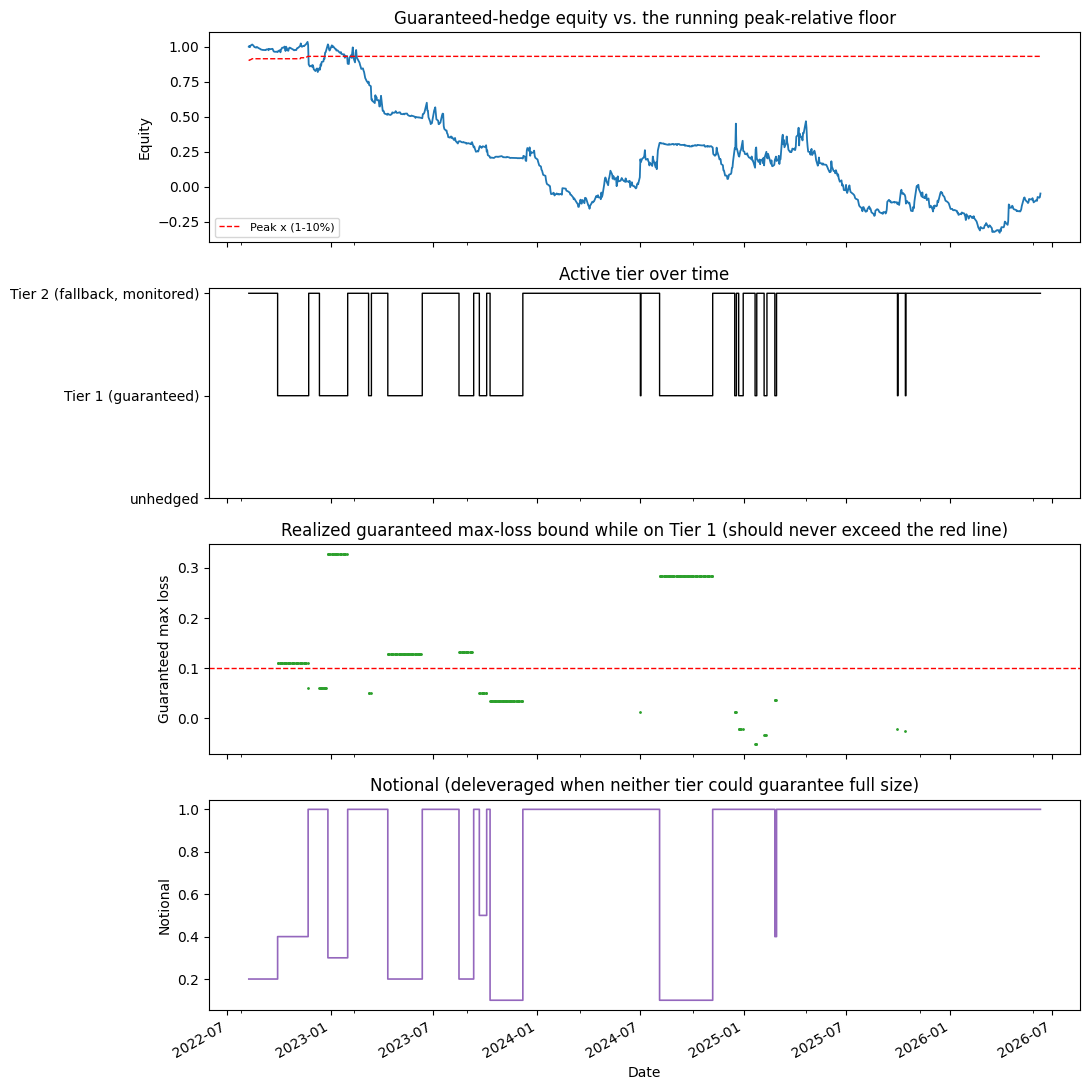

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

equity.plot(ax=axes[0], linewidth=1.3, color="tab:blue")
running_floor = (1 - LOSS_TOLERANCE) * equity.cummax()
running_floor.plot(ax=axes[0], linewidth=1, color="red", linestyle="--", label=f"Peak x (1-{LOSS_TOLERANCE:.0%})")
axes[0].set_title("Guaranteed-hedge equity vs. the running peak-relative floor")
axes[0].set_ylabel("Equity")
axes[0].legend(fontsize=8)

tier_track.plot(ax=axes[1], linewidth=1.0, color="black", drawstyle="steps-post")
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(["unhedged", "Tier 1 (guaranteed)", "Tier 2 (fallback, monitored)"])
axes[1].set_title("Active tier over time")

guaranteed_bound.plot(ax=axes[2], linewidth=1.0, color="tab:green", marker=".", markersize=2, linestyle="none")
axes[2].axhline(LOSS_TOLERANCE, color="red", linestyle="--", linewidth=1)
axes[2].set_title("Realized guaranteed max-loss bound while on Tier 1 (should never exceed the red line)")
axes[2].set_ylabel("Guaranteed max loss")

notional_track.plot(ax=axes[3], linewidth=1.2, color="tab:purple", drawstyle="steps-post")
axes[3].set_title("Notional (deleveraged when neither tier could guarantee full size)")
axes[3].set_ylabel("Notional")

fig.tight_layout()
plt.show()


## Risk metrics -- Sharpe, Max DD, CAGR, etc.

In [8]:
eq_returns = equity.pct_change().dropna()
risk = summarize(equity, eq_returns, "Guaranteed hedge (Tier 1 + Tier 2 fallback)")
pd.DataFrame([risk])


,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,Guaranteed hedge (Tier 1 + Tier 2 fallback),-1.0,10.526233,-0.694935,-1.317424,-0.759057


## Proactive worst-case sizing -- a genuinely never-breach approach

Everything above is unchanged. This is an additional, separate run of the exact same
`simulate_guaranteed_hedge` -- it already takes `notional` as a parameter -- called with a
much smaller starting size instead of $1.

The idea: instead of running near full size and reacting *after* a bad move (which we
showed is mathematically impossible to fully protect against once the true peak never
resets -- you cannot un-lose money that's already lost), size the position **upfront** so
small that even the worst single-day move ever observed in this data couldn't breach the
10% floor in the first place, even with zero hedge response. No reset needed anywhere,
because the breach becomes structurally unreachable rather than something to recover from.

Trade-off, explicit: this costs a lot of return, most of the time, in exchange for the
guarantee being real rather than best-effort.

In [9]:
r_tsll_full = tsll_spot_full.pct_change().dropna()
worst_1day_move = r_tsll_full.max()          # largest single-day TSLL rise (hurts the short)
worst_2day_move = ((1 + r_tsll_full).rolling(2).apply(lambda x: x.prod() - 1, raw=True)).max()

# Solve: notional x worst_move <= LOSS_TOLERANCE  ->  notional <= LOSS_TOLERANCE / worst_move
MAX_SAFE_NOTIONAL_1D = LOSS_TOLERANCE / worst_1day_move
MAX_SAFE_NOTIONAL_2D = LOSS_TOLERANCE / worst_2day_move

print(f"Worst observed single-day TSLL move: {worst_1day_move:.1%}  -> max safe notional (1-day basis): {MAX_SAFE_NOTIONAL_1D:.3f}")
print(f"Worst observed 2-day cumulative move: {worst_2day_move:.1%}  -> max safe notional (2-day basis): {MAX_SAFE_NOTIONAL_2D:.3f}")

CONSERVATIVE_NOTIONAL = MAX_SAFE_NOTIONAL_2D  # stricter of the two -- accounts for one missed daily check
print(f"\nUsing notional = {CONSERVATIVE_NOTIONAL:.3f} (~{CONSERVATIVE_NOTIONAL:.0%} of the original $1)")


Worst observed single-day TSLL move: 45.2%  -> max safe notional (1-day basis): 0.221
Worst observed 2-day cumulative move: 53.2%  -> max safe notional (2-day basis): 0.188

Using notional = 0.188 (~19% of the original $1)


## Run the identical simulation, just starting from the conservative size

In [10]:
equity_sleeve, tier_track_cons, guaranteed_bound_cons, notional_track_cons, stats_cons = \
    simulate_guaranteed_hedge(dates, notional=CONSERVATIVE_NOTIONAL)

# equity_sleeve starts at CONSERVATIVE_NOTIONAL (the at-risk position alone). The rest of
# the original $1 sits in cash, untouched, never exposed to TSLL/TSLA moves at all -- add
# it back so the blended series reflects the TRUE total-portfolio percentage risk, not the
# at-risk sleeve's own (unchanged) percentage volatility.
cash_sleeve = 1.0 - CONSERVATIVE_NOTIONAL
equity_cons = cash_sleeve + equity_sleeve

dd_cons = equity_cons / equity_cons.cummax() - 1
print(stats_cons)
print(f"\nMax drawdown from peak (blended, total portfolio): {dd_cons.min():.4f} on {dd_cons.idxmin().date()}")
print(f"Final equity (blended, starts at 1.0 like the full-size run): {equity_cons.iloc[-1]:.4f}")

eq_returns_cons = equity_cons.pct_change().dropna()
risk_cons = summarize(equity_cons, eq_returns_cons, "Conservative (worst-case-gap-sized, blended with cash)")
pd.DataFrame([risk_cons])


{'forced_rolls': 1, 'tier1_restorations': 11, 'tier2_falls_back': 409, 'peak_rechecks': 2, 'tier2_drift_resizes': 14, 'notional_changes': 17, 'floor_breaches': 409, 'floor_breached_last_resort': 4, 'days_tier1': 271, 'days_tier2': 692, 'days_unhedged': 0}

Max drawdown from peak (blended, total portfolio): -0.2547 on 2026-03-30
Final equity (blended, starts at 1.0 like the full-size run): 0.8028


,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,"Conservative (worst-case-gap-sized, blended wi...",-0.055642,0.089888,-0.594949,-0.254662,-0.218493


## Compare: full-size (reactive) vs. conservative (proactive) -- equity and drawdown

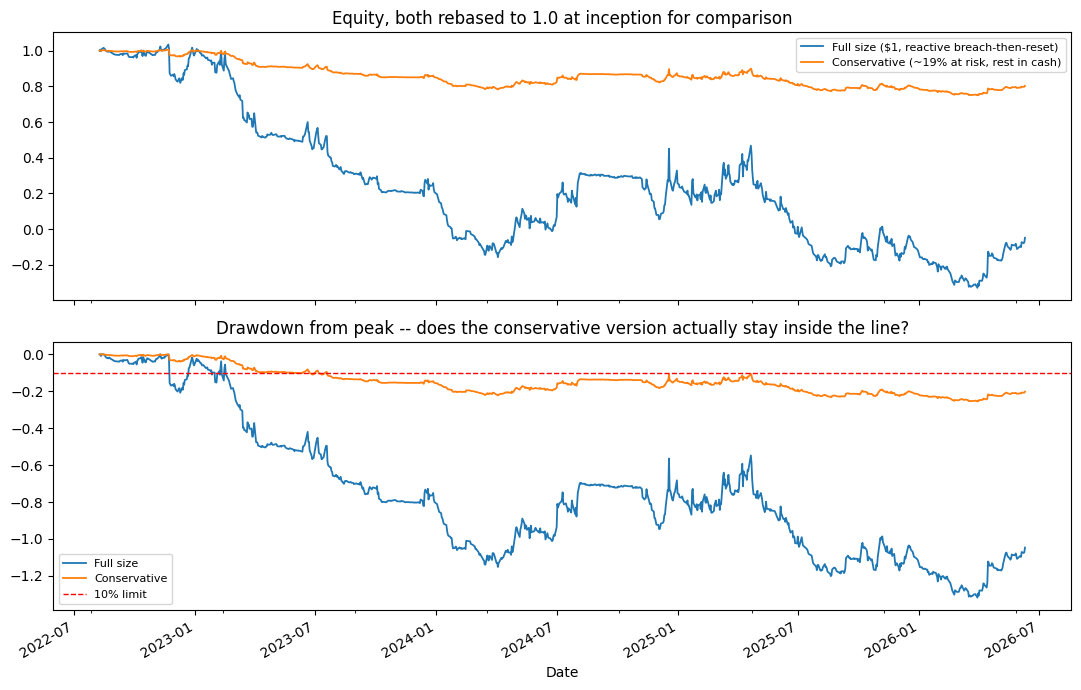

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

(equity / equity.iloc[0]).plot(ax=axes[0], label="Full size ($1, reactive breach-then-reset)", linewidth=1.3)
equity_cons.plot(ax=axes[0], label=f"Conservative (~{CONSERVATIVE_NOTIONAL:.0%} at risk, rest in cash)", linewidth=1.3)
axes[0].set_title("Equity, both rebased to 1.0 at inception for comparison")
axes[0].legend(fontsize=8)

dd_full = equity / equity.cummax() - 1
dd_full.plot(ax=axes[1], label="Full size", linewidth=1.3)
dd_cons.plot(ax=axes[1], label="Conservative", linewidth=1.3)
axes[1].axhline(-LOSS_TOLERANCE, color="red", linestyle="--", linewidth=1, label="10% limit")
axes[1].set_title("Drawdown from peak -- does the conservative version actually stay inside the line?")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


## Dynamic recap -- resize the safe sleeve against CURRENT total equity, periodically

Fixes the growth problem: the safe-notional cap above was computed once, against the
original $1, and never revisited -- so once the sleeve compounded well past its starting
size, the same worst-case-move cushion no longer covered the now-larger position.

Two changes, both just orchestration around the *existing*, unmodified
`simulate_guaranteed_hedge` -- called repeatedly on successive date segments rather than
once on the whole range:

1. **Recap period** (~monthly, `RECAP_FREQUENCY_DAYS` trading days): at each boundary,
   recompute `safe_notional = (LOSS_TOLERANCE / worst_case_move) x current_total_equity`
   using whatever the total portfolio is worth *right now*, not the original $1. Cash
   sleeve is `current_total_equity - safe_notional`, held flat until the next recap.
2. **Expanding-window worst-case move**, not the full-history number used above. Using the
   entire dataset's worst move (found via 45.2% on 2025-04-09) to size a segment running in
   2022 would be lookahead -- that crash hadn't happened yet. Each recap only uses moves
   observed strictly before it, consistent with the no-fitted-parameters approach used
   everywhere else in this notebook. Necessary honest caveat: past worst-case is a proxy
   for future worst-case, not a guarantee one won't be exceeded -- especially early on, when
   the expanding window is thin.

In [12]:
RECAP_FREQUENCY_DAYS = 21  # ~monthly

# expanding-window worst 1-day / 2-day moves, using only data up to and including each date
r_2day_full = (1 + r_tsll_full).rolling(2).apply(lambda x: x.prod() - 1, raw=True)
expanding_worst_1d = r_tsll_full.expanding(min_periods=1).max()
expanding_worst_2d = r_2day_full.expanding(min_periods=2).max()


def dynamic_recap_strategy(dates, loss_tolerance, recap_freq=RECAP_FREQUENCY_DAYS):
    total_equity = 1.0
    segments = []
    segment_stats = []
    caps_used = []

    start_idx = 0
    while start_idx < len(dates):
        end_idx = min(start_idx + recap_freq, len(dates))
        segment_dates = dates[start_idx:end_idx]

        # only use worst-case data known strictly before this segment starts
        as_of = dates[start_idx - 1] if start_idx > 0 else dates[0]
        w1 = expanding_worst_1d.loc[:as_of].iloc[-1] if as_of in expanding_worst_1d.loc[:as_of].index else expanding_worst_1d.iloc[0]
        w2 = expanding_worst_2d.loc[:as_of].dropna()
        w2 = w2.iloc[-1] if len(w2) else w1
        worst_move_known = max(w1, w2, 0.01)  # floor to avoid a division blow-up on day 1

        safe_fraction = min(loss_tolerance / worst_move_known, 1.0)  # never lever above 100%
        safe_notional = safe_fraction * total_equity
        cash_portion = total_equity - safe_notional
        caps_used.append({"date": segment_dates[0], "worst_move_known": worst_move_known,
                          "safe_fraction": safe_fraction, "total_equity": total_equity})

        eq_seg, tier_seg, gb_seg, nt_seg, stats_seg = simulate_guaranteed_hedge(segment_dates, notional=safe_notional)
        blended_seg = cash_portion + eq_seg
        segments.append(blended_seg)
        segment_stats.append(stats_seg)

        total_equity = float(blended_seg.iloc[-1])
        start_idx = end_idx

    full_equity = pd.concat(segments)
    caps_df = pd.DataFrame(caps_used).set_index("date")
    return full_equity, segment_stats, caps_df


equity_dynamic, stats_dynamic_segments, caps_df = dynamic_recap_strategy(dates, LOSS_TOLERANCE)
dd_dynamic = equity_dynamic / equity_dynamic.cummax() - 1

print(f"Number of recap segments: {len(stats_dynamic_segments)}")
print(f"Max drawdown from peak: {dd_dynamic.min():.4f} on {dd_dynamic.idxmin().date()}")
print(f"Final equity: {equity_dynamic.iloc[-1]:.4f}")
caps_df.describe()


Number of recap segments: 46
Max drawdown from peak: -0.2453 on 2026-05-28
Final equity: 0.8108


,worst_move_known,safe_fraction,total_equity
count,46.000000,46.000000,46.000000
mean,0.398815,0.310052,0.878060
std,0.136614,0.204956,0.053639
min,0.054704,0.188100,0.803399
25%,0.356041,0.188100,0.838959
50%,0.362135,0.276141,0.877569
75%,0.531632,0.280866,0.906186
max,0.531632,1.000000,1.001762


## Risk metrics -- dynamically recapped

In [13]:
eq_returns_dynamic = equity_dynamic.pct_change().dropna()
risk_dynamic = summarize(equity_dynamic, eq_returns_dynamic, "Dynamic recap (resized every ~month)")
pd.DataFrame([risk_dynamic])


,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,Dynamic recap (resized every ~month),-0.053196,0.170318,-0.23706,-0.245265,-0.216892


## Compare all three: full-size, fixed-conservative, dynamically recapped

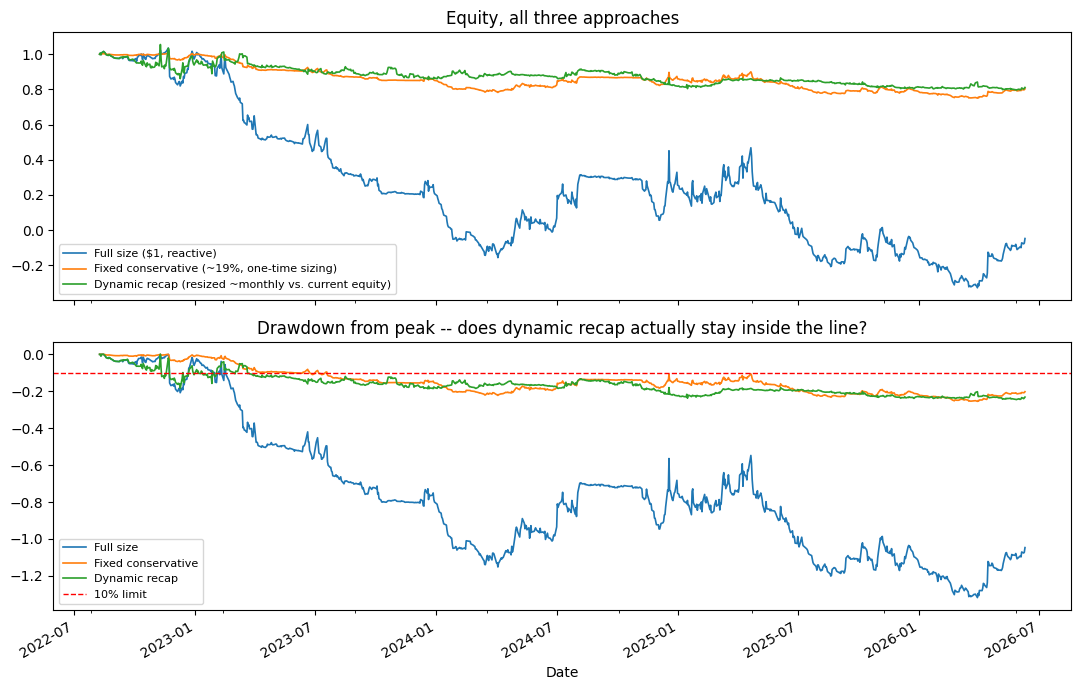

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

equity.plot(ax=axes[0], label="Full size ($1, reactive)", linewidth=1.2)
equity_cons.plot(ax=axes[0], label=f"Fixed conservative (~{CONSERVATIVE_NOTIONAL:.0%}, one-time sizing)", linewidth=1.2)
equity_dynamic.plot(ax=axes[0], label="Dynamic recap (resized ~monthly vs. current equity)", linewidth=1.2)
axes[0].set_title("Equity, all three approaches")
axes[0].legend(fontsize=8)

dd_full.plot(ax=axes[1], label="Full size", linewidth=1.2)
dd_cons.plot(ax=axes[1], label="Fixed conservative", linewidth=1.2)
dd_dynamic.plot(ax=axes[1], label="Dynamic recap", linewidth=1.2)
axes[1].axhline(-LOSS_TOLERANCE, color="red", linestyle="--", linewidth=1, label="10% limit")
axes[1].set_title("Drawdown from peak -- does dynamic recap actually stay inside the line?")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


## Dynamic recap with an explicit safety buffer

Two additions on top of the expanding-window logic above, both addressing the same root
cause: a record-breaking move is by definition worse than anything seen before it, so
sizing off the raw observed worst-case is always caught flat-footed the first time a new
record gets set.

1. **`SAFETY_MULTIPLIER`**: assume the next bad day could be this many times worse than
   the worst one observed so far, not exactly as bad and no worse.
2. **`MIN_ASSUMED_WORST_MOVE`**: an absolute floor on the assumed worst case, independent of
   how little history has been observed -- addresses the early-period problem directly,
   where the expanding window started at ~5% and let `safe_fraction` go all the way to
   100%. TSLA/TSLL are known to be extremely volatile instruments regardless of what
   the first few weeks of data happen to show; the floor encodes that prior instead of
   learning it the hard way.

Same orchestration as before, still just calling the unmodified `simulate_guaranteed_hedge`
repeatedly.

In [15]:
SAFETY_MULTIPLIER = 2.5       # assume the next bad day could be 2.5x worse than any seen so far
MIN_ASSUMED_WORST_MOVE = 0.30  # floor -- never assume less than a 30% possible single-day move,
                                # regardless of how calm the data has looked so far


def dynamic_recap_strategy_safe(dates, loss_tolerance, recap_freq=RECAP_FREQUENCY_DAYS,
                                 safety_multiplier=SAFETY_MULTIPLIER, min_assumed=MIN_ASSUMED_WORST_MOVE):
    total_equity = 1.0
    segments = []
    segment_stats = []
    caps_used = []

    start_idx = 0
    while start_idx < len(dates):
        end_idx = min(start_idx + recap_freq, len(dates))
        segment_dates = dates[start_idx:end_idx]

        as_of = dates[start_idx - 1] if start_idx > 0 else dates[0]
        w1 = expanding_worst_1d.loc[:as_of].iloc[-1] if as_of in expanding_worst_1d.loc[:as_of].index else expanding_worst_1d.iloc[0]
        w2 = expanding_worst_2d.loc[:as_of].dropna()
        w2 = w2.iloc[-1] if len(w2) else w1
        worst_move_observed = max(w1, w2, 0.01)
        worst_move_assumed = max(worst_move_observed * safety_multiplier, min_assumed)

        safe_fraction = min(loss_tolerance / worst_move_assumed, 1.0)
        safe_notional = safe_fraction * total_equity
        cash_portion = total_equity - safe_notional
        caps_used.append({"date": segment_dates[0], "worst_move_observed": worst_move_observed,
                          "worst_move_assumed": worst_move_assumed, "safe_fraction": safe_fraction,
                          "total_equity": total_equity})

        eq_seg, tier_seg, gb_seg, nt_seg, stats_seg = simulate_guaranteed_hedge(segment_dates, notional=safe_notional)
        blended_seg = cash_portion + eq_seg
        segments.append(blended_seg)
        segment_stats.append(stats_seg)

        total_equity = float(blended_seg.iloc[-1])
        start_idx = end_idx

    full_equity = pd.concat(segments)
    caps_df_safe = pd.DataFrame(caps_used).set_index("date")
    return full_equity, segment_stats, caps_df_safe


equity_safe, stats_safe_segments, caps_df_safe = dynamic_recap_strategy_safe(dates, LOSS_TOLERANCE)
dd_safe = equity_safe / equity_safe.cummax() - 1

print(f"Number of recap segments: {len(stats_safe_segments)}")
print(f"Max drawdown from peak: {dd_safe.min():.4f} on {dd_safe.idxmin().date()}")
print(f"Final equity: {equity_safe.iloc[-1]:.4f}")
caps_df_safe.describe()


Number of recap segments: 46
Max drawdown from peak: -0.1023 on 2026-05-28
Final equity: 0.9256


,worst_move_observed,worst_move_assumed,safe_fraction,total_equity
count,46.000000,46.000000,46.000000,46.000000
mean,0.398815,1.001334,0.121708,0.953987
std,0.136614,0.331518,0.074937,0.022003
min,0.054704,0.300000,0.075240,0.922131
25%,0.356041,0.890103,0.075240,0.937964
50%,0.362135,0.905336,0.110456,0.954291
75%,0.531632,1.329079,0.112347,0.966535
max,0.531632,1.329079,0.333333,1.005078


## Risk metrics -- dynamic recap with safety buffer

In [16]:
eq_returns_safe = equity_safe.pct_change().dropna()
risk_safe = summarize(equity_safe, eq_returns_safe, "Dynamic recap + safety buffer")
pd.DataFrame([risk_safe])


,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,Dynamic recap + safety buffer,-0.019968,0.067682,-0.265268,-0.10233,-0.195132


## Compare all four approaches

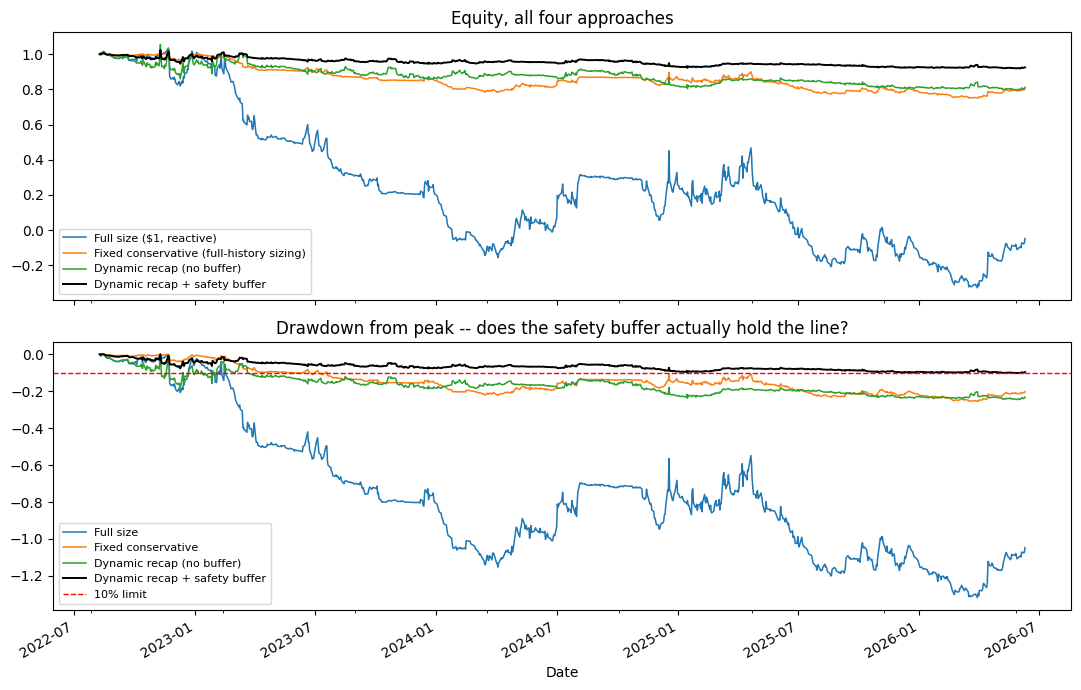

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

equity.plot(ax=axes[0], label="Full size ($1, reactive)", linewidth=1.1)
equity_cons.plot(ax=axes[0], label="Fixed conservative (full-history sizing)", linewidth=1.1)
equity_dynamic.plot(ax=axes[0], label="Dynamic recap (no buffer)", linewidth=1.1)
equity_safe.plot(ax=axes[0], label="Dynamic recap + safety buffer", linewidth=1.4, color="black")
axes[0].set_title("Equity, all four approaches")
axes[0].legend(fontsize=8)

dd_full.plot(ax=axes[1], label="Full size", linewidth=1.1)
dd_cons.plot(ax=axes[1], label="Fixed conservative", linewidth=1.1)
dd_dynamic.plot(ax=axes[1], label="Dynamic recap (no buffer)", linewidth=1.1)
dd_safe.plot(ax=axes[1], label="Dynamic recap + safety buffer", linewidth=1.4, color="black")
axes[1].axhline(-LOSS_TOLERANCE, color="red", linestyle="--", linewidth=1, label="10% limit")
axes[1].set_title("Drawdown from peak -- does the safety buffer actually hold the line?")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


## Volatility-based sizing, capped by what Tier 1 can actually guarantee

Root cause, confirmed with data: at full size, `protection_ref` doesn't stabilize -- it
grinds from 1.02 down through zero to -0.31 by 2026, because breaches recur roughly every
2.3 days and each one is a fresh ~10% hit. That's not a bug in the reset logic, it's
TSLA/TSLL's actual volatility being incompatible with a tight, frequently-checked 10% band
at full notional. Sizing has to absorb that, properly, not as an afterthought.

**Two independent, equally-weighted constraints -- take the smaller (more conservative):**

1. **Statistical**: `LOSS_TOLERANCE / (Z x daily_vol)`, using rolling realized vol
   (`tsll_sigma_full`) combined with a worst-observed-move backstop, recomputed weekly.
   Z=8.5 is calibrated against real history -- the worst observed move was an 8.4-sigma
   event relative to the *prevailing* vol right before it (2024-10-24: 43.7% move on a
   quiet 5.2%-vol day), not an arbitrary buffer.
2. **Hard guarantee**: the largest notional at which Tier 1's algebraic search
   (`find_cheapest_guaranteed_call`) can actually find a qualifying TSLL contract *today*.
   Not a statistical estimate -- the same payoff-algebra bound from the start of this
   notebook, used here to directly cap position size instead of being merely "tried first
   and hoped for."

Whichever constraint is tighter at a given recap point wins -- both matter equally, per
your instruction.

In [18]:
Z_SIGMA = 8.5                  # calibrated against the worst observed vol-adjusted move (8.41)
RECAP_FREQUENCY_DAYS_FAST = 5  # weekly -- reacts to a shifting vol regime faster than monthly

tsll_sigma_1d = r_tsll_full.rolling(VOL_WINDOW).std()  # daily (not annualized) realized vol


def largest_tier1_feasible_notional(as_of_date, ref_eq, cur_eq, cap):
    """Search NOTIONAL_GRID top-down for the largest notional (capped at `cap`) at which
    Tier 1's algebraic guarantee search actually finds a qualifying TSLL contract today.
    Returns 0.0 if nothing is guaranteeable at any tested size."""
    spot_now = float(tsll_spot_full.loc[as_of_date])
    for frac in NOTIONAL_GRID:
        test_notional = cap * frac
        if test_notional > cap:
            continue
        test_shares = test_notional / spot_now
        row1 = find_cheapest_guaranteed_call(tsll_calls, spot_now, as_of_date, LOSS_TOLERANCE,
                                             test_shares, ref_eq, cur_eq)
        if row1 is not None:
            return test_notional
    return 0.0


def largest_tier2_feasible_notional(as_of_date, ref_eq, cur_eq, cap):
    """Same idea, for Tier 2: largest notional (capped at `cap`) at which the cheapest
    available TSLA call both exists AND doesn't itself breach the floor when paid for.
    Not a guarantee (Tier 2 never is), but explicitly capping by this at the sizing level
    instead of leaving it to the daily loop to discover mid-segment."""
    sig_now = float(tsla_sigma_full.loc[as_of_date]) if as_of_date in tsla_sigma_full.index else 0.5
    floor = (1 - LOSS_TOLERANCE) * ref_eq
    for frac in NOTIONAL_GRID:
        test_notional = cap * frac
        if test_notional > cap:
            continue
        pos2 = find_cheapest_tier2_call(tsla_spot_full.loc[as_of_date], sig_now, test_notional, as_of_date)
        if pos2 is not None and (cur_eq - pos2["premium_cost"]) >= floor:
            return test_notional
    return 0.0


def dynamic_recap_strategy_vol(dates, loss_tolerance, recap_freq=RECAP_FREQUENCY_DAYS_FAST,
                                z_sigma=Z_SIGMA, safety_multiplier=SAFETY_MULTIPLIER, min_assumed=MIN_ASSUMED_WORST_MOVE):
    total_equity = 1.0
    segments = []
    segment_stats = []
    caps_used = []

    start_idx = 0
    while start_idx < len(dates):
        end_idx = min(start_idx + recap_freq, len(dates))
        segment_dates = dates[start_idx:end_idx]
        as_of = dates[start_idx - 1] if start_idx > 0 else dates[0]

        # constraint 1: statistical (vol-based + worst-observed-move backstop)
        vol_now = tsll_sigma_1d.loc[:as_of].dropna()
        vol_now = float(vol_now.iloc[-1]) if len(vol_now) else 0.10
        vol_based_move = z_sigma * vol_now

        w1 = expanding_worst_1d.loc[:as_of].iloc[-1] if as_of in expanding_worst_1d.loc[:as_of].index else expanding_worst_1d.iloc[0]
        w2 = expanding_worst_2d.loc[:as_of].dropna()
        w2 = w2.iloc[-1] if len(w2) else w1
        worst_move_observed = max(w1, w2, 0.01)
        move_based_move = max(worst_move_observed * safety_multiplier, min_assumed)

        worst_move_assumed = max(vol_based_move, move_based_move)  # more conservative of the two
        statistical_notional = min(loss_tolerance / worst_move_assumed, 1.0) * total_equity

        # constraint 2: hard guarantee -- largest notional Tier 1 can actually cover today
        guaranteed_notional = largest_tier1_feasible_notional(as_of, total_equity, total_equity, total_equity)

        # constraint 3: same idea for Tier 2 -- largest notional it can affordably cover today
        tier2_notional = largest_tier2_feasible_notional(as_of, total_equity, total_equity, total_equity)

        either_tier_covers = max(guaranteed_notional, tier2_notional)
        safe_notional = min(statistical_notional, either_tier_covers) if either_tier_covers > 0 else statistical_notional
        cash_portion = total_equity - safe_notional
        caps_used.append({"date": segment_dates[0], "vol_based_move": vol_based_move,
                          "move_based_move": move_based_move, "statistical_notional": statistical_notional,
                          "guaranteed_notional": guaranteed_notional, "tier2_notional": tier2_notional,
                          "safe_notional": safe_notional, "total_equity": total_equity})

        eq_seg, tier_seg, gb_seg, nt_seg, stats_seg = simulate_guaranteed_hedge(segment_dates, notional=safe_notional)
        blended_seg = cash_portion + eq_seg
        segments.append(blended_seg)
        segment_stats.append(stats_seg)

        total_equity = float(blended_seg.iloc[-1])
        start_idx = end_idx

    full_equity = pd.concat(segments)
    caps_df_vol = pd.DataFrame(caps_used).set_index("date")
    return full_equity, segment_stats, caps_df_vol


equity_vol, stats_vol_segments, caps_df_vol = dynamic_recap_strategy_vol(dates, LOSS_TOLERANCE)
dd_vol = equity_vol / equity_vol.cummax() - 1

print(f"Number of recap segments: {len(stats_vol_segments)}")
print(f"Max drawdown from peak: {dd_vol.min():.4f} on {dd_vol.idxmin().date()}")
print(f"Final equity: {equity_vol.iloc[-1]:.4f}")
print(f"\nFraction of segments where the statistical constraint was the binding (smallest) one:")
print((caps_df_vol["safe_notional"] >= caps_df_vol["statistical_notional"] - 1e-9).mean())
caps_df_vol.describe()


Number of recap segments: 193
Max drawdown from peak: -0.1082 on 2026-01-22
Final equity: 0.9823

Fraction of segments where the statistical constraint was the binding (smallest) one:
0.9948186528497409


,vol_based_move,move_based_move,statistical_notional,guaranteed_notional,tier2_notional,safe_notional,total_equity
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000
mean,0.544096,1.008758,0.109610,0.846425,0.370524,0.108917,1.026104
std,0.209233,0.323343,0.044776,0.255925,0.159486,0.042244,0.032013
min,0.247850,0.300000,0.073251,0.000000,0.195035,0.073251,0.973570
25%,0.403588,0.890103,0.075158,0.684888,0.293337,0.075158,0.998590
50%,0.485417,0.906220,0.115284,0.979974,0.315570,0.115284,1.034250
75%,0.632046,1.329079,0.118714,1.041691,0.421563,0.118714,1.051372
max,1.247679,1.329079,0.334316,1.082320,1.049473,0.332353,1.082320


## Risk metrics -- volatility-based sizing

In [19]:
eq_returns_vol = equity_vol.pct_change().dropna()
risk_vol = summarize(equity_vol, eq_returns_vol, "Volatility-based sizing (weekly recap)")
pd.DataFrame([risk_vol])


,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,Volatility-based sizing (weekly recap),-0.004658,0.046949,-0.076356,-0.108158,-0.043068


## Compare all five approaches

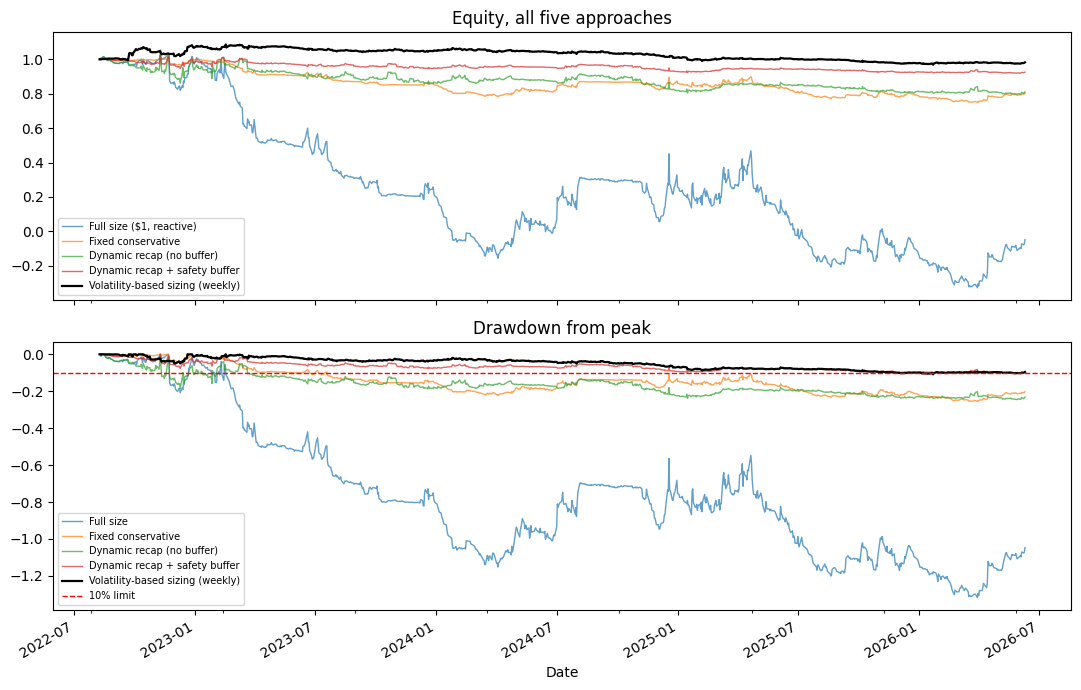

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

equity.plot(ax=axes[0], label="Full size ($1, reactive)", linewidth=1.0, alpha=0.7)
equity_cons.plot(ax=axes[0], label="Fixed conservative", linewidth=1.0, alpha=0.7)
equity_dynamic.plot(ax=axes[0], label="Dynamic recap (no buffer)", linewidth=1.0, alpha=0.7)
equity_safe.plot(ax=axes[0], label="Dynamic recap + safety buffer", linewidth=1.0, alpha=0.7)
equity_vol.plot(ax=axes[0], label="Volatility-based sizing (weekly)", linewidth=1.6, color="black")
axes[0].set_title("Equity, all five approaches")
axes[0].legend(fontsize=7)

dd_full.plot(ax=axes[1], label="Full size", linewidth=1.0, alpha=0.7)
dd_cons.plot(ax=axes[1], label="Fixed conservative", linewidth=1.0, alpha=0.7)
dd_dynamic.plot(ax=axes[1], label="Dynamic recap (no buffer)", linewidth=1.0, alpha=0.7)
dd_safe.plot(ax=axes[1], label="Dynamic recap + safety buffer", linewidth=1.0, alpha=0.7)
dd_vol.plot(ax=axes[1], label="Volatility-based sizing (weekly)", linewidth=1.6, color="black")
axes[1].axhline(-LOSS_TOLERANCE, color="red", linestyle="--", linewidth=1, label="10% limit")
axes[1].set_title("Drawdown from peak")
axes[1].legend(fontsize=7)

fig.tight_layout()
plt.show()


## The real tradeoff: position size vs. risk ceiling

Same sizing methodology (statistical vol-based, capped by both tiers' actual guarantee/
affordability), just swept across `LOSS_TOLERANCE` instead of fixed at 10%. This is the
actual lever -- how much size can the PM meaningfully run at each risk ceiling, and what
does that cost in realized Max DD and return.

In [21]:
LOSS_TOLERANCE_GRID = [0.10, 0.15, 0.20, 0.25]

ceiling_results = []
ceiling_equities = {}
ceiling_caps = {}

for lt in LOSS_TOLERANCE_GRID:
    eq_lt, stats_lt, caps_lt = dynamic_recap_strategy_vol(dates, lt)
    dd_lt = eq_lt / eq_lt.cummax() - 1
    risk_lt = summarize(eq_lt, eq_lt.pct_change().dropna(), f"Ceiling {lt:.0%}")
    risk_lt["Realized Max DD"] = dd_lt.min()
    risk_lt["Avg safe_notional"] = caps_lt["safe_notional"].mean()
    risk_lt["Final equity"] = eq_lt.iloc[-1]
    ceiling_results.append(risk_lt)
    ceiling_equities[lt] = eq_lt
    ceiling_caps[lt] = caps_lt

ceiling_df = pd.DataFrame(ceiling_results)
ceiling_df


,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar,Realized Max DD,Avg safe_notional,Final equity
0,Ceiling 10%,-0.004658,0.046949,-0.076356,-0.108158,-0.043068,-0.108158,0.108917,0.982250
1,Ceiling 15%,-0.006794,0.070267,-0.062344,-0.158230,-0.042937,-0.158230,0.165671,0.974190
2,Ceiling 20%,-0.009561,0.093355,-0.056859,-0.205783,-0.046461,-0.205783,0.223186,0.963821
3,Ceiling 25%,-0.014141,0.115737,-0.066066,-0.250927,-0.056356,-0.250927,0.279164,0.946836


## Plot: equity and drawdown across all four ceilings

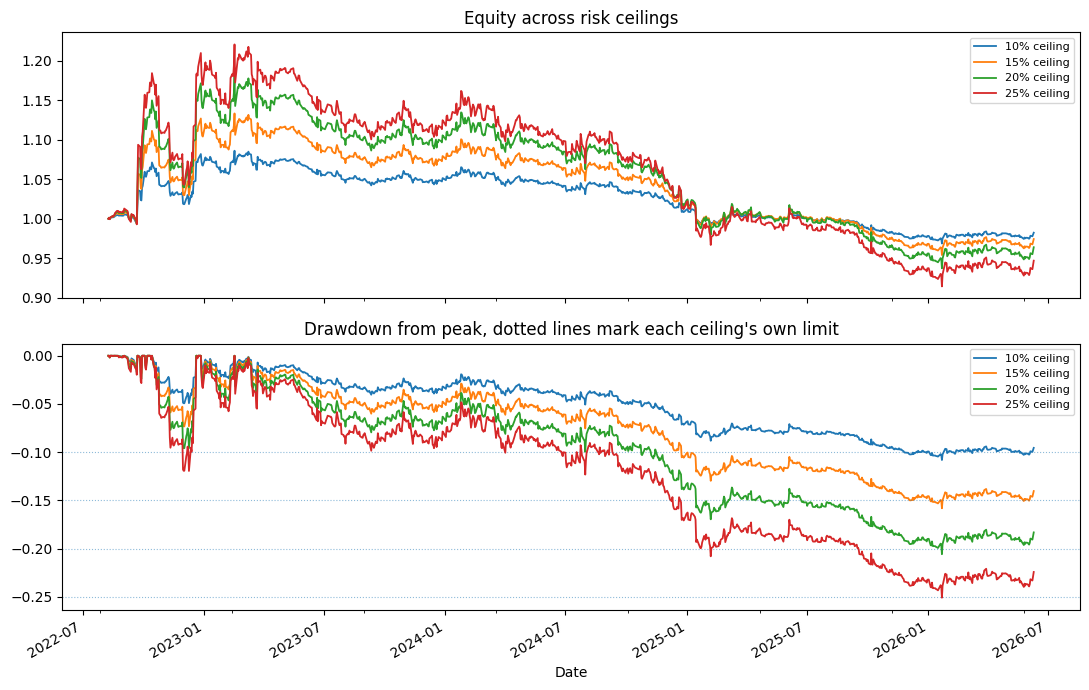

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for lt in LOSS_TOLERANCE_GRID:
    ceiling_equities[lt].plot(ax=axes[0], label=f"{lt:.0%} ceiling", linewidth=1.3)
axes[0].set_title("Equity across risk ceilings")
axes[0].legend(fontsize=8)

for lt in LOSS_TOLERANCE_GRID:
    dd_lt = ceiling_equities[lt] / ceiling_equities[lt].cummax() - 1
    dd_lt.plot(ax=axes[1], label=f"{lt:.0%} ceiling", linewidth=1.3)
    axes[1].axhline(-lt, linestyle=":", linewidth=0.8, alpha=0.5)
axes[1].set_title("Drawdown from peak, dotted lines mark each ceiling's own limit")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()
